# Evaluasi Semua Model pada Seluruh Subset Dataset

Notebook ini mengevaluasi semua `best.pt` dari training tiap split terhadap `dataset/test`, `dataset/train`, `dataset/valid`, dan gabungan ketiganya. Hasil evaluasi disimpan sebagai CSV dan grafik lokal.

In [2]:
from pathlib import Path
import re
import shutil

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from ultralytics import YOLO

In [3]:
# Konfigurasi utama
DATASET_ROOT = Path("dataset")
WEIGHTS_ROOT = Path("runs/detect/results/yolo_v12/feedback_reviewer/training/nano")
EVAL_DATASET_ROOT = Path("evaluation_dataset")
EVAL_RESULTS_ROOT = Path("evaluation_results/all_dataset_evaluation")

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
CLASS_NAMES = ["frog-eye-leaf-spot", "healthy", "rust"]
IMGSZ = 640
BATCH = 16

# Jika True, folder gabungan all akan dibuat ulang dari nol.
FORCE_REBUILD_ALL_DATASET = False

EVAL_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

In [4]:
def natural_split_key(path: Path) -> int:
    match = re.search(r"split_(\d+)", str(path))
    return int(match.group(1)) if match else 10**9

def sanitize_name(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", name).strip("_")

def count_files(folder: Path, exts: set[str] | None = None) -> int:
    if not folder.exists():
        return 0
    if exts is None:
        return sum(1 for p in folder.iterdir() if p.is_file())
    return sum(1 for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts)

def write_eval_yaml(yaml_path: Path, subset_root: Path) -> Path:
    names_text = "[" + ", ".join(repr(name) for name in CLASS_NAMES) + "]"
    yaml_text = (
        f"path: {subset_root.resolve().as_posix()}\n"
        "train: images\n"
        "val: images\n"
        "test: images\n\n"
        f"nc: {len(CLASS_NAMES)}\n"
        f"names: {names_text}\n"
    )
    yaml_path.parent.mkdir(parents=True, exist_ok=True)
    yaml_path.write_text(yaml_text, encoding="utf-8")
    return yaml_path

def image_to_label_path(image_path: Path, subset_root: Path) -> Path:
    return subset_root / "labels" / f"{image_path.stem}.txt"

def prepare_all_subset(force_rebuild: bool = False) -> Path:
    all_root = EVAL_DATASET_ROOT / "all"
    all_images = all_root / "images"
    all_labels = all_root / "labels"

    if force_rebuild and all_root.exists():
        shutil.rmtree(all_root)

    all_images.mkdir(parents=True, exist_ok=True)
    all_labels.mkdir(parents=True, exist_ok=True)

    if count_files(all_images, IMG_EXTS) > 0 and not force_rebuild:
        return all_root

    for subset_name in ["train", "test", "valid"]:
        subset_root = DATASET_ROOT / subset_name
        for image_path in sorted((subset_root / "images").iterdir()):
            if not image_path.is_file() or image_path.suffix.lower() not in IMG_EXTS:
                continue

            label_path = image_to_label_path(image_path, subset_root)
            if not label_path.exists():
                print(f"Label tidak ditemukan, dilewati: {label_path}")
                continue

            new_stem = f"{subset_name}__{image_path.stem}"
            shutil.copy2(image_path, all_images / f"{new_stem}{image_path.suffix.lower()}")
            shutil.copy2(label_path, all_labels / f"{new_stem}.txt")

    return all_root

def prepare_eval_datasets() -> dict[str, Path]:
    eval_yamls = {}

    source_subsets = {
        "test": DATASET_ROOT / "test",
        "train": DATASET_ROOT / "train",
        "valid": DATASET_ROOT / "valid",
    }

    for subset_name, subset_root in source_subsets.items():
        if not (subset_root / "images").exists() or not (subset_root / "labels").exists():
            raise FileNotFoundError(f"Folder subset tidak lengkap: {subset_root}")
        eval_yamls[subset_name] = write_eval_yaml(EVAL_DATASET_ROOT / f"{subset_name}.yaml", subset_root)

    all_root = prepare_all_subset(FORCE_REBUILD_ALL_DATASET)
    eval_yamls["all"] = write_eval_yaml(EVAL_DATASET_ROOT / "all.yaml", all_root)

    for subset_name, yaml_path in eval_yamls.items():
        subset_root = Path(yaml_path.read_text().splitlines()[0].replace("path: ", ""))
        print(
            f"{subset_name}: "
            f"images={count_files(subset_root / 'images', IMG_EXTS)}, "
            f"labels={count_files(subset_root / 'labels')} -> {yaml_path}"
        )

    return eval_yamls

eval_yamls = prepare_eval_datasets()

test: images=2190, labels=2190 -> evaluation_dataset\test.yaml
train: images=7638, labels=7638 -> evaluation_dataset\train.yaml
valid: images=1093, labels=1093 -> evaluation_dataset\valid.yaml
all: images=10921, labels=10921 -> evaluation_dataset\all.yaml


In [7]:
# Model dari semua split training yang sudah punya best.pt
split_models = []
for weight_path in sorted(WEIGHTS_ROOT.glob("split_*/weights/best.pt"), key=natural_split_key):
    split_size = natural_split_key(weight_path)
    if split_size not in [750, 1000, 1250, 1500, 1750, 2000, 3000, 4000]:
        split_models.append({
            "label": f"nano_split_{split_size}",
            "path": weight_path,
            "source": "split_training",
            "enabled": True,
        })

# Placeholder few-shot learning. Isi path lalu ubah enabled menjadi True.
few_shot_models = [
    {
        "label": "few_shot_model_medium-40k",
        "path": Path("best_model/medium-40k/best.pt"),
        "source": "few_shot_placeholder",
        "enabled": True,
    },
]

model_configs = split_models + few_shot_models
models_df = pd.DataFrame([
    {**cfg, "path": str(cfg["path"]), "path_exists": cfg["path"].exists()}
    for cfg in model_configs
])
display(models_df)

,label,path,source,enabled,path_exists
0,nano_split_100,runs\detect\results\yolo_v12\feedback_reviewer...,split_training,True,True
1,nano_split_200,runs\detect\results\yolo_v12\feedback_reviewer...,split_training,True,True
2,nano_split_300,runs\detect\results\yolo_v12\feedback_reviewer...,split_training,True,True
3,nano_split_400,runs\detect\results\yolo_v12\feedback_reviewer...,split_training,True,True
4,nano_split_500,runs\detect\results\yolo_v12\feedback_reviewer...,split_training,True,True
5,nano_split_600,runs\detect\results\yolo_v12\feedback_reviewer...,split_training,True,True
6,nano_split_700,runs\detect\results\yolo_v12\feedback_reviewer...,split_training,True,True
7,few_shot_model_medium-40k,best_model\medium-40k\best.pt,few_shot_placeholder,True,True


In [8]:
def read_result_metrics(result) -> dict:
    return {
        "precision": float(result.box.mp),
        "recall": float(result.box.mr),
        "mAP50": float(result.box.map50),
        "mAP50_95": float(result.box.map),
    }

def save_class_metrics(result, csv_path: Path) -> None:
    names = result.names
    df = pd.DataFrame({
        "class": [names[i] for i in range(len(names))],
        "precision": result.box.p.tolist(),
        "recall": result.box.r.tolist(),
        "mAP50": result.box.ap50.tolist(),
        "mAP50_95": result.box.maps.tolist(),
    })
    all_row = pd.DataFrame([{
        "class": "all",
        "precision": float(result.box.mp),
        "recall": float(result.box.mr),
        "mAP50": float(result.box.map50),
        "mAP50_95": float(result.box.map),
    }])
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    pd.concat([all_row, df], ignore_index=True).to_csv(csv_path, index=False)

def evaluate_models(model_configs: list[dict], eval_yamls: dict[str, Path], resume: bool = True) -> pd.DataFrame:
    summary_csv = EVAL_RESULTS_ROOT / "evaluation_summary.csv"
    if resume and summary_csv.exists():
        rows = pd.read_csv(summary_csv).to_dict("records")
    else:
        rows = []

    completed = {
        (row["model_label"], row["subset"])
        for row in rows
        if pd.notna(row.get("mAP50")) and pd.notna(row.get("mAP50_95"))
    }

    for cfg in model_configs:
        if not cfg.get("enabled", True):
            print(f"Lewati {cfg['label']}: disabled")
            continue

        weight_path = Path(cfg["path"])
        if not weight_path.exists():
            print(f"Lewati {cfg['label']}: weight tidak ditemukan -> {weight_path}")
            continue

        model_label = cfg["label"]
        model = None

        for subset_name, yaml_path in eval_yamls.items():
            if (model_label, subset_name) in completed:
                print(f"Lewati {model_label} subset {subset_name}: sudah ada di summary CSV")
                continue

            if model is None:
                model = YOLO(str(weight_path))

            run_name = sanitize_name(f"{model_label}_{subset_name}")
            print(f"Evaluasi {model_label} ke subset {subset_name}")

            result = model.val(
                data=str(yaml_path),
                split="val",
                imgsz=IMGSZ,
                batch=BATCH,
                project=str(EVAL_RESULTS_ROOT / "yolo_val"),
                name=run_name,
                exist_ok=True,
                plots=True,
            )

            subset_root = Path(yaml_path.read_text().splitlines()[0].replace("path: ", ""))
            metrics = read_result_metrics(result)
            row = {
                "model_label": model_label,
                "model_source": cfg.get("source", "unknown"),
                "weight_path": str(weight_path),
                "subset": subset_name,
                "images": count_files(subset_root / "images", IMG_EXTS),
                **metrics,
                "save_dir": str(result.save_dir),
            }
            rows.append(row)
            completed.add((model_label, subset_name))

            save_class_metrics(
                result,
                EVAL_RESULTS_ROOT / "class_metrics" / f"{run_name}_class_metrics.csv",
            )
            pd.DataFrame(rows).to_csv(summary_csv, index=False)

    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_csv, index=False)
    return summary_df

summary_df = evaluate_models(model_configs, eval_yamls, resume=True)
display(summary_df)
print(f"Summary evaluasi disimpan ke: {EVAL_RESULTS_ROOT / 'evaluation_summary.csv'}")

Evaluasi nano_split_100 ke subset test
Ultralytics 8.4.0  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 74.015.7 MB/s, size: 48.5 KB)
val: Scanning C:\Users\abiyamf\Documents\Code Program\Thesis\new_experiment_for_feedback_reviewer\dataset\test\labels.cache... 2190 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2190/2190  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 137/137 9.1it/s 15.1s<0.1s
                   all       2190       4225      0.359      0.425      0.455      0.416
    frog-eye-leaf-spot        850       1145      0.546      0.622      0.578      0.543
               healthy        930       2569      0.531      0.652      0.647      0.581
                  rust        413        511          0          0      0.138      0.123
Speed: 0.7

,model_label,model_source,weight_path,subset,images,precision,recall,mAP50,mAP50_95,save_dir
0,nano_split_750,split_training,runs\detect\results\yolo_v12\feedback_reviewer...,test,2190,0.892119,0.847314,0.929108,0.860264,C:\Users\abiyamf\Documents\Code Program\Thesis...
1,nano_split_750,split_training,runs\detect\results\yolo_v12\feedback_reviewer...,train,7638,0.892055,0.841909,0.931134,0.865501,C:\Users\abiyamf\Documents\Code Program\Thesis...
2,nano_split_750,split_training,runs\detect\results\yolo_v12\feedback_reviewer...,valid,1093,0.906430,0.835416,0.933981,0.865096,C:\Users\abiyamf\Documents\Code Program\Thesis...
3,nano_split_750,split_training,runs\detect\results\yolo_v12\feedback_reviewer...,all,10921,0.888888,0.845720,0.929997,0.863361,C:\Users\abiyamf\Documents\Code Program\Thesis...
4,nano_split_1000,split_training,runs\detect\results\yolo_v12\feedback_reviewer...,test,2190,0.894030,0.859107,0.936904,0.875452,C:\Users\abiyamf\Documents\Code Program\Thesis...
...,...,...,...,...,...,...,...,...,...,...
59,nano_split_700,split_training,runs\detect\results\yolo_v12\feedback_reviewer...,all,10921,0.873875,0.800617,0.893866,0.839083,C:\Users\abiyamf\Documents\Code Program\Thesis...
60,few_shot_model_medium-40k,few_shot_placeholder,best_model\medium-40k\best.pt,test,2190,0.665394,0.656107,0.709377,0.604314,C:\Users\abiyamf\Documents\Code Program\Thesis...
61,few_shot_model_medium-40k,few_shot_placeholder,best_model\medium-40k\best.pt,train,7638,0.662347,0.663838,0.714597,0.612632,C:\Users\abiyamf\Documents\Code Program\Thesis...
62,few_shot_model_medium-40k,few_shot_placeholder,best_model\medium-40k\best.pt,valid,1093,0.662482,0.636445,0.697262,0.588105,C:\Users\abiyamf\Documents\Code Program\Thesis...


Summary evaluasi disimpan ke: evaluation_results\all_dataset_evaluation\evaluation_summary.csv


In [9]:
summary_csv = EVAL_RESULTS_ROOT / "evaluation_summary.csv"
summary_df = pd.read_csv(summary_csv)

subset_order = ["train", "test", "valid", "all"]
summary_df["subset"] = pd.Categorical(summary_df["subset"], categories=subset_order, ordered=True)
summary_df = summary_df.sort_values(["model_label", "subset"])

def plot_metric(metric: str, ylabel: str, filename: str) -> None:
    pivot_df = summary_df.pivot(index="model_label", columns="subset", values=metric)
    pivot_df = pivot_df[[subset for subset in subset_order if subset in pivot_df.columns]]

    ax = pivot_df.plot(kind="bar", figsize=(14, 7), width=0.82)
    ax.set_title(f"Perbandingan {ylabel} Tiap Model pada Seluruh Subset")
    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Subset")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    output_path = EVAL_RESULTS_ROOT / filename
    plt.savefig(output_path, dpi=200)
    plt.show()
    print(f"Grafik disimpan ke: {output_path}")

plot_metric("mAP50", "mAP50", "comparison_map50_by_model_and_subset.png")
plot_metric("mAP50_95", "mAP50-95", "comparison_map50_95_by_model_and_subset.png")
plot_metric("precision", "Precision", "comparison_precision_by_model_and_subset.png")
plot_metric("recall", "Recall", "comparison_recall_by_model_and_subset.png")

<Figure size 1400x700 with 1 Axes>

Grafik disimpan ke: evaluation_results\all_dataset_evaluation\comparison_map50_by_model_and_subset.png


<Figure size 1400x700 with 1 Axes>

Grafik disimpan ke: evaluation_results\all_dataset_evaluation\comparison_map50_95_by_model_and_subset.png


<Figure size 1400x700 with 1 Axes>

Grafik disimpan ke: evaluation_results\all_dataset_evaluation\comparison_precision_by_model_and_subset.png


<Figure size 1400x700 with 1 Axes>

Grafik disimpan ke: evaluation_results\all_dataset_evaluation\comparison_recall_by_model_and_subset.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TypeError: unsupported operand type(s) for /: 'str' and 'str'

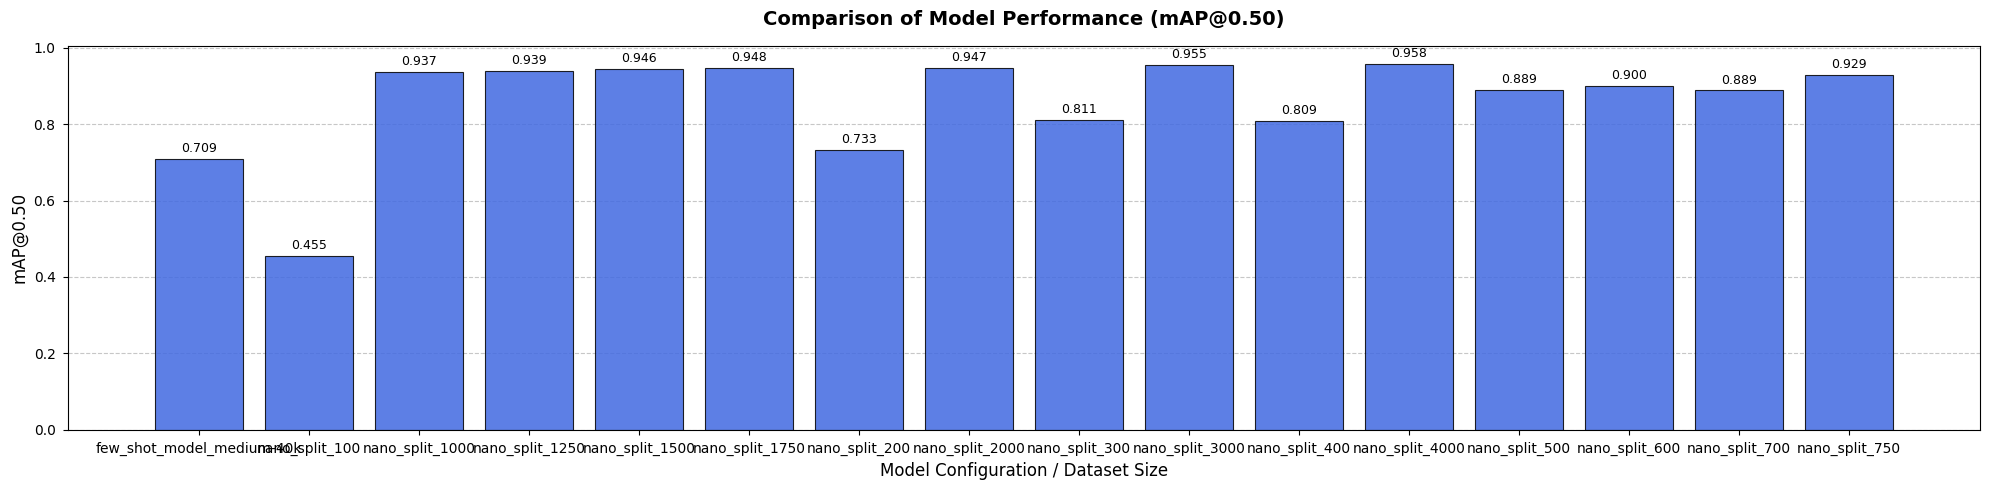

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Filter Data
summary_csv = "evaluation_results/all_dataset_evaluation/evaluation_summary.csv"
EVAL_RESULTS_ROOT = "evaluation_results/all_dataset_evaluation"
df = pd.read_csv(summary_csv)

# Only use 'test' subset as requested
df_test = df[df["subset"] == "test"].copy()

# Sort by model label (ensure 750 is visible in context)
df_test = df_test.sort_values("model_label")

def plot_paper_metric(metric: str, ylabel: str, filename: str):
    """
    Plots a publication-quality bar chart for a specific metric.
    """
    # Set professional style
    plt.style.use('seaborn-v0_8-paper') # or 'ggplot' if seaborn is unavailable
    fig, ax = plt.subplots(figsize=(20, 5))

    # Create the bar plot
    # Using a single professional color (e.g., 'steelblue' or 'gray') 
    # to maintain paper neutrality
    bars = ax.bar(df_test["model_label"], df_test[metric], 
                  color='royalblue', alpha=0.85, edgecolor='black', linewidth=0.8)

    # Add text labels on top of bars for clarity
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    # Labeling
    ax.set_title(f"Comparison of Model Performance ({ylabel})", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Model Configuration / Dataset Size", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Paper-friendly adjustments
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True) # Grid behind bars
    plt.xticks(rotation=0, fontsize=10) # Set to 0 if labels are short (e.g., numbers)
    plt.yticks(fontsize=10)
    
    # Optional: Highlight the "750" data point if it's named specifically
    # for bar in bars:
    #     if "750" in str(bar.get_x()): bar.set_color('darkorange')

    plt.tight_layout()

    # Save for paper (PDF is often preferred for high-quality LaTeX documents)
    output_path = EVAL_RESULTS_ROOT / filename
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Publication-ready graph saved to: {output_path}")

# Generate Plots for the Paper
plot_paper_metric("mAP50", "mAP@0.50", "test_comparison_map50.png")
plot_paper_metric("mAP50_95", "mAP@0.50:0.95", "test_comparison_map50_95.png")
plot_paper_metric("precision", "Precision", "test_comparison_precision.png")
plot_paper_metric("recall", "Recall", "test_comparison_recall.png")

In [10]:
from pathlib import Path

# 1. Setup Paths
EVAL_RESULTS_ROOT = Path("evaluation_results/all_dataset_evaluation")
summary_csv = EVAL_RESULTS_ROOT / "evaluation_summary.csv"

# 2. Load and Clean Data
df = pd.read_csv(summary_csv)

# Filter: Only use 'test' subset and exclude the specific large model
df = df[df["subset"] == "test"]
df = df[df["model_label"] != "few_shot_model_medium-40k"]

# Clean Labels: Remove 'nano_split_' prefix to leave only the number
df["model_label"] = df["model_label"].str.replace("nano_split_", "", regex=False)

# Ensure numeric sorting (so 1000 comes after 750, not after 100)
df["model_label_int"] = pd.to_numeric(df["model_label"])
df = df.sort_values("model_label_int")

def plot_paper_metric(metric: str, ylabel: str, filename: str):
    """
    Plots a professional bar chart to demonstrate performance saturation.
    """
    # Professional style settings
    plt.style.use('seaborn-v0_8-paper') 
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot bars with a neutral, academic color palette
    color_main = '#2c3e50'  # Dark blue-grey
    bars = ax.bar(df["model_label"], df[metric], 
                  color=color_main, alpha=0.85, edgecolor='black', linewidth=0.8)

    # Add data labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # English Labeling for Paper
    ax.set_title(f"Model Performance Comparison: {ylabel}", fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Number of Training Samples", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Refining Aesthetics
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True) # Grid behind bars
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    
    # Adjust Y-axis limit to give space for labels
    ax.set_ylim(0, max(df[metric]) * 1.15)

    plt.tight_layout()

    # Save with high resolution (DPI 300)
    output_path = EVAL_RESULTS_ROOT / filename
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Paper-ready chart saved to: {output_path}")

# 3. Generate the required plots
metrics_to_plot = [
    ("mAP50", "mAP@0.50", "test_comparison_map50.png"),
    ("mAP50_95", "mAP@0.50:0.95", "test_comparison_map50_95.png"),
    ("precision", "Precision", "test_comparison_precision.png"),
    ("recall", "Recall", "test_comparison_recall.png")
]

for metric, ylabel, fname in metrics_to_plot:
    plot_paper_metric(metric, ylabel, fname)

Paper-ready chart saved to: evaluation_results\all_dataset_evaluation\test_comparison_map50.png
Paper-ready chart saved to: evaluation_results\all_dataset_evaluation\test_comparison_map50_95.png
Paper-ready chart saved to: evaluation_results\all_dataset_evaluation\test_comparison_precision.png
Paper-ready chart saved to: evaluation_results\all_dataset_evaluation\test_comparison_recall.png
